# Model-based T1 reconstruction (BART `moba -L`) — synthetic phantom, V1

First, **untuned** version of the model-based alternative to the joint-LLR reconstruction
(`RECON_COMPARISON.md`, method 2). Instead of reconstructing four TI images and fitting T1
voxel by voxel, `moba` estimates the parameter maps of the IR signal model — and the coil
sensitivities — **directly from the undersampled k-space of all four TIs at once**
(Wang et al., MRM 2018;79:730, doi:10.1002/mrm.26726): a nonlinear inverse problem solved
with the iteratively regularised Gauss-Newton method (IRGNM), each Newton step's linear
subproblem solved by FISTA with a joint l1-wavelet penalty on the parameter maps.

**Data: synthetic phantom only** (`synth/phantom.py`); no subject data are used.

| step | what | section |
|---|---|---|
| 0 | verify that the protocol's IR equation is exactly `moba -L`'s model; TI file units/dims | 3 |
| 1 | load and stack the 4 TIs per plane and echo group (`pipeline_utils.stack_tis`) | 4 |
| 2 | remove the per-TI global phase offsets (moba shares one complex image across TIs) | 5 |
| 3 | coil sensitivities: what `moba -L` can and cannot take | 6 |
| 4 | `moba -L` per echo group → M_ss, M0', R1* | 7-8 |
| 5 | T1 = 1/R1*, combine echo groups, evaluate vs truth | 9-10 |
| 6 | model-consistency checks: synthesised TI images, k-space residual, M0'/M_ss | 11-12 |
| 7 | coil-map QC, LLR reference for context, all planes | 13-15 |
| 8 | what a per-plane T1 output means for 3-plane super-resolution; report | 16-17 |

**No tuning.** Every `moba` option below is a documented starting value (BART defaults or
BART's own test settings). Regularisation, iterations and scaling are to be tuned later
with the researcher; section 17 lists them.

> **Status (V1, hand-over):** partially executed. Sections 1-10 have outputs (coronal); the rest is written but not run. See section 17.

## 1. Environment

In [1]:
import os
import sys
import time
import json
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

os.environ.setdefault('BART_TOOLBOX_PATH', str(Path('~/bart').expanduser()))
REPO = Path.cwd()
sys.path.insert(0, str(REPO / 'synth'))
import pipeline_utils as pu                      # shared conventions (do not re-implement)
from pipeline_utils import bart
from phantom import load_scans

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
BART_BIN = os.path.join(os.environ['BART_TOOLBOX_PATH'], 'bart')
print(subprocess.run([BART_BIN, 'version'], capture_output=True, text=True).stdout.strip(),
      '|', os.environ['BART_TOOLBOX_PATH'])

v1.0.00 | /Users/jackewins/bart


## 2. Configuration

The phantom lives outside the repo (`python synth/phantom.py ~/work/phantom`); derived
data are cached in `PROC_DIR` (also outside the repo). Delete a cache file to force a re-run.

`moba` starting options (all **untuned**):

| option | value | meaning / source |
|---|---|---|
| `-L` | | 3-parameter IR Look-Locker model S = M_ss − (M_ss + M0') e^(−TI·R1*) |
| `-l1` | | joint l1-wavelet penalty on the 3 parameter maps (Wang 2018; moba default) |
| `-i` | 8 | IRGNM (Newton) steps — moba default |
| `-C` | 100 | max. FISTA iterations per Newton step (moba caps step n at min(C, 10·2^n)) |
| `-j` | 0.01 | minimum regularisation α_min; α_n = α_min + (1 − α_min)/2^n (`-R 2` default) — BART's tests use 0.01 |
| `--normalize_scaling --scale_data 5000 --scale_psf 1000` | | data and PSF normalised to fixed norms: the historical hard-coded moba scaling, still used in BART's `moba` tests |
| init | M_ss = M0' = 1, R1* = 1 s⁻¹ | moba default (`--other pinit` to change) |
| R1* ≥ 0 | | moba default (last map constrained) |

In [2]:
PHANTOM_DIR = Path(os.environ.get('QT1_PHANTOM_DIR', '~/work/phantom')).expanduser()
PROC_DIR    = PHANTOM_DIR / 'moba'            # derived data, outside the repo
PROC_DIR.mkdir(exist_ok=True)

PLANE          = 'COR'                        # end-to-end validation plane
RUN_ALL_PLANES = True                         # section 15 (AX, SAG as well; ~1.5 h per plane)

# ---- moba (untuned starting values) ------------------------------------------
MOBA_NEWTON    = 8
MOBA_INNER     = 100
MOBA_REG       = '-l1'
MOBA_ALPHA_MIN = 0.01
MOBA_SCALING   = '--normalize_scaling --scale_data 5000 --scale_psf 1000'
MOBA_OPTS = f'-L {MOBA_REG} -i {MOBA_NEWTON} -C {MOBA_INNER} -j {MOBA_ALPHA_MIN} {MOBA_SCALING}'
MOBA_JOBS      = 6       # readout slices reconstructed in parallel (section 7), 1 thread each

# ---- per-TI global phase (section 5) -----------------------------------------
PHASE_CORR  = True       # demodulate the per-TI global phase before moba
PHASE_TAPER = 0.15       # Gaussian k-space taper (SD as a fraction of the matrix) for the estimate

# ---- echo groups (section 9) ------------------------------------------------
ECHO_COMBINE = 'mean_R1'   # average R1* of the two echo groups, T1 = 1 / mean

MOBA_TAG = f'2d_L{MOBA_REG}_i{MOBA_NEWTON}_C{MOBA_INNER}_j{MOBA_ALPHA_MIN}_ph{int(PHASE_CORR)}'
scans = load_scans(PHANTOM_DIR)
PLANES = tuple(scans)
print('phantom:', PHANTOM_DIR, '| planes', PLANES, '| cache', PROC_DIR)
print('moba', MOBA_OPTS)

phantom: /Users/jackewins/work/moba/phantom | planes ('AX', 'COR', 'SAG') | cache /Users/jackewins/work/moba/phantom/moba
moba -L -l1 -i 8 -C 100 -j 0.01 --normalize_scaling --scale_data 5000 --scale_psf 1000


## 3. Does `moba -L` fit our signal model? (numerical verification)

The protocol's IR-FSE signal (full inversion, readout, recovery of length c = TR − TI):

$$S(TI) = M_0\left(1 - 2e^{-TI/T_1} + e^{-TR/T_1}\right),\qquad TR = TI + c$$

`moba -L` fits (BART `src/moba/T1fun.c`, "Mss − (Mss + M0)·exp(−t·R1s)"):

$$S(TI) = M_{ss} - (M_{ss} + M_0')\,e^{-TI\,R_1^*}$$

Substituting TR = TI + c: S = M0 − M0 (2 − e^(−c/T1)) e^(−TI/T1), so the two are identical with

$$M_{ss} = M_0,\qquad M_0' = M_0\left(1 - e^{-c/T_1}\right),\qquad R_1^* = 1/T_1$$

— **provided c is the same at every TI**. There is no Look-Locker flip-angle correction here
(no continuous FLASH readout during recovery), so T1 = 1/R1* directly; BART's `looklocker`
tool (T1 = M0'/(M_ss·R1*)) must **not** be applied.

Two consequences:

* moba does not know c and does not impose M0' = M0 (1 − e^(−c/T1)); M0' is a free (complex)
  parameter. moba therefore fits 3 parameters (plus phases) to 4 TIs, where the PSIR grid fit
  (`fit_t1_grid`, TR known) fits 2. Less constrained → more noise, and sensitive to model
  errors for long T1 (below).
* The protocol does **not** have one c: TI31 has TR = 1.225 s (c = 1.19425 s), the others
  c = 1.200 s. The second cell quantifies the resulting error by fitting the moba model
  (3 free parameters, least squares, noise-free) to the exact protocol signal.

In [3]:
TI_s = {p: np.array([s['info']['TI_s'] for s in scans[p]]) for p in PLANES}
TR_s = {p: np.array([s['info']['TR_s'] for s in scans[p]]) for p in PLANES}
for p in PLANES[1:]:
    assert np.allclose(TI_s[p], TI_s[PLANES[0]]) and np.allclose(TR_s[p], TR_s[PLANES[0]])
TI, TR = TI_s[PLANE], TR_s[PLANE]
print('TI (s):', TI, '\nTR (s):', TR, '\nc = TR - TI (s):', TR - TI)


def ir_model(M0, T1, ti, tr):
    return M0 * (1 - 2 * np.exp(-ti / T1) + np.exp(-tr / T1))


def ll_model(Mss, M0p, R1, ti):
    return Mss - (Mss + M0p) * np.exp(-ti * R1)


T1_grid = np.logspace(np.log10(0.1), np.log10(4.0), 300)          # s
C_NOM = 1.2
err = max(np.abs(ir_model(1.0, t, TI, TI + C_NOM)
                 - ll_model(1.0, 1 - np.exp(-C_NOM / t), 1 / t, TI)).max() for t in T1_grid)
print(f'\n(a) exact mapping, c = {C_NOM} s at every TI: max |S_IR - S_moba| / M0 = {err:.1e} '
      f'over T1 = 0.1-4 s')

TI (s): [0.03075 0.15    0.4     0.8    ] 
TR (s): [1.225 1.35  1.6   2.   ] 
c = TR - TI (s): [1.19425 1.2     1.2     1.2    ]

(a) exact mapping, c = 1.2 s at every TI: max |S_IR - S_moba| / M0 = 4.4e-16 over T1 = 0.1-4 s


(b) T1 bias from c(TI31) = 1.19425 s vs 1.200 s (noise-free, moba model fitted to the exact protocol signal)
 T1 true (ms)  T1 moba (ms)   bias %  M_ss/M0 max resid/M0
        183.0         183.0    0.003   1.0000      4.9e-06
        258.6         258.6    0.021   1.0001      3.3e-05
        307.3         307.4    0.043   1.0002      6.7e-05
        339.2         339.4    0.062   1.0003      9.7e-05
        497.2         498.3    0.214   1.0015      2.6e-04
       1004.5        1016.6    1.199   1.0120      5.3e-04
       2004.5        2094.2    4.473   1.0498      5.2e-04
       3492.4        3885.3   11.252   1.1247      4.0e-04

signal difference at TI31: 2.0e-04 M0 (T1 260 ms), 1.2e-03 M0 (T1 3.5 s)


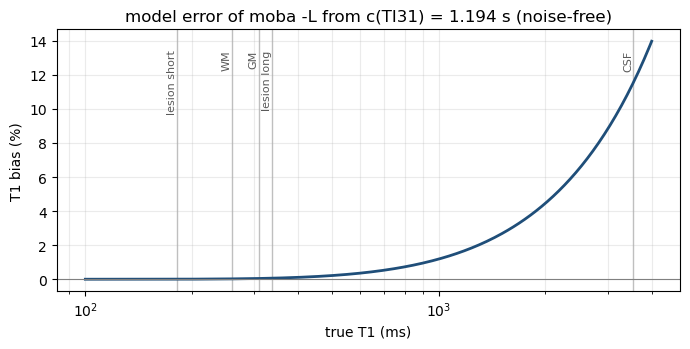

In [4]:
# (b) the real protocol (c = 1.19425 s at TI31): fit moba's 3 free parameters to the exact signal
fit = []
for t in T1_grid:
    s = ir_model(1.0, t, TI, TR)
    r = least_squares(lambda q: ll_model(q[0], q[1], q[2], TI) - s,
                      [1.0, 1 - np.exp(-C_NOM / t), 1 / t], xtol=1e-15, ftol=1e-15, gtol=1e-15)
    fit.append((1 / r.x[2], r.x[0], r.x[1], np.abs(r.fun).max()))
fit = np.array(fit)
bias_model = 100 * (fit[:, 0] - T1_grid) / T1_grid

print('(b) T1 bias from c(TI31) = 1.19425 s vs 1.200 s (noise-free, moba model fitted to the '
      'exact protocol signal)')
print(f"{'T1 true (ms)':>13s} {'T1 moba (ms)':>13s} {'bias %':>8s} {'M_ss/M0':>8s} {'max resid/M0':>12s}")
for t in (0.182, 0.26, 0.309, 0.338, 0.5, 1.0, 2.0, 3.5):
    i = np.argmin(np.abs(T1_grid - t))
    print(f'{1000 * T1_grid[i]:13.1f} {1000 * fit[i, 0]:13.1f} {bias_model[i]:8.3f} '
          f'{fit[i, 1]:8.4f} {fit[i, 3]:12.1e}')
d31 = [ir_model(1, t, TI[0], TR[0]) - ir_model(1, t, TI[0], TI[0] + C_NOM) for t in (0.26, 3.5)]
print(f'\nsignal difference at TI31: {d31[0]:.1e} M0 (T1 260 ms), {d31[1]:.1e} M0 (T1 3.5 s)')

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogx(1000 * T1_grid, bias_model, color='#1f4e79', lw=2)
for t, n in ((182, 'lesion short'), (260, 'WM'), (309, 'GM'), (338, 'lesion long'), (3543, 'CSF')):
    ax.axvline(t, color='0.75', lw=1, zorder=0)
    ax.text(t, ax.get_ylim()[1] * 0.92, n, rotation=90, ha='right', va='top', fontsize=8, color='0.35')
ax.axhline(0, color='0.5', lw=0.8)
ax.set_xlabel('true T1 (ms)'); ax.set_ylabel('T1 bias (%)')
ax.set_title('model error of moba -L from c(TI31) = 1.194 s (noise-free)')
ax.grid(alpha=0.25, which='both'); plt.tight_layout(); plt.show()

**Result.** (a) With a single c the mapping is exact to machine precision. (b) The
6 ms shorter recovery at TI31 changes the signal by ~2·10⁻⁴ M0 in WM, which moves the
fitted T1 by **< 0.1 % for all brain tissue and lesions (180-340 ms)** — negligible
against partial volume and noise. It grows with T1 (≈ 1 % at 1 s) and is **≈ +11 % for
CSF** (3.5 s): with TIs ≤ 0.8 s a CSF curve is still in its early, almost linear part, the
3-parameter fit is ill-conditioned there, and a tiny model error moves M_ss and R1*
together. CSF T1 from moba is therefore biased by the model alone (in addition to the
partial-volume shift in `ideal`) and not reliable at this TI range.

### TI file: units and dimensions

`moba` multiplies the TI array directly by R1* (`T1fun.c`: exp(−t·R1s), with parameter
scaling 1), so **the units of R1* are the inverse of the TI file's units**. BART's own
`moba` tests and Wang's scripts use seconds; we do the same, so R1* is in s⁻¹ and
T1 (ms) = 1000 / R1*. The file must be a complex array of shape
**(1, 1, 1, 1, 1, n_TI)** — TIs along dim 5 (TE_DIM), matching the k-space
(`moba.c` asserts `TI_dims[TE_DIM] == ksp_dims[TE_DIM]`). The initial R1* = 1 s⁻¹
(T1 = 1 s) is within a factor 4 of brain T1 and 3.5 of CSF.

In [5]:
def ti_file(scans_plane):
    return np.array([s['info']['TI_s'] for s in scans_plane], np.complex64).reshape(1, 1, 1, 1, 1, -1)


print('TI file', ti_file(scans[PLANE]).shape, np.real(ti_file(scans[PLANE])).ravel(), '(s)')

TI file (1, 1, 1, 1, 1, 4) [0.03075 0.15    0.4     0.8    ] (s)


## 4. Stack the TIs per plane and echo group

`pipeline_utils.stack_tis` puts the 4 TIs along dim 5, the dimension `moba` treats as the
signal-model dimension (TI/TE). The trajectory is passed as a wrapper keyword argument
(`t=T`). The coronal and sagittal TIs have equal PE counts; axial TI31 has 992 vs 800, so
the other axial TIs are zero-padded and `stack_tis` returns a zero-weight pattern `P`.

**`moba -p` is not a sampling weight.** In `moba`, `-p <PSF>` means *pre-gridded Cartesian
k-space plus its point-spread function* (the `-p psf.ra k_space.ra` usage in BART's tests);
it is not the per-sample weight file of `pics -p`, and passing `P` there would be wrong.
It is also unnecessary: with `-t`, `moba` builds its PSF from the data itself —
`estimate_pattern()` (`src/misc/mri2.c`) sets the weight of every sample to 1 where the
coil RSS is non-zero and 0 elsewhere — so the zero-padded samples get zero weight and add
nothing to the gridded data either. The cell below confirms that the padded samples are
exactly zero in every coil (so `estimate_pattern` removes exactly them).

In [6]:
for p in PLANES:
    T, D, P = pu.stack_tis(scans[p], 0)
    zero = np.all(D == 0, axis=3)[0, :, :, 0, :]                 # (read, pe, TI): all coils zero
    msg = 'no padding'
    if P is not None:
        pad = np.real(P[0, :, :, 0, 0, :]) == 0                  # (read, pe, TI)
        msg = (f'padded samples per TI {pad.sum(axis=(0, 1))}; all-coil-zero samples '
               f'{zero.sum(axis=(0, 1))}; identical: {np.array_equal(pad, zero)}')
    print(f'{p:4s} traj{T.shape} data{D.shape}  {msg}')

AX   traj(3, 100, 992, 1, 1, 4) data(1, 100, 992, 8, 1, 4)  padded samples per TI [    0 19200 19200 19200]; all-coil-zero samples [    0 19200 19200 19200]; identical: True
COR  traj(3, 112, 736, 1, 1, 4) data(1, 112, 736, 8, 1, 4)  no padding
SAG  traj(3, 122, 672, 1, 1, 4) data(1, 122, 672, 8, 1, 4)  no padding


## 5. Per-TI global phase

`moba -L` has **one complex M_ss and one complex M0' per voxel** shared by all TIs (R1* is
real). A smooth phase common to all TIs (background, coils, the extra phase of echo group 1)
is absorbed by the complex maps and the jointly estimated coils. A **global phase that
differs between TI scans** (measured 4-9° on real data; SD 5° in the phantom) is not in the
model and would be fitted as a spurious curve shape.

**First approach (implemented): estimate and demodulate in k-space.** A constant phase
multiplies k-space linearly, so each TI's data are multiplied by e^(−iΔφ_j) before `moba`.
Δφ_j (relative to the reference TI, TI800) comes from per-coil low-resolution gridding
images g_{j,c} (adjoint NUFFT with a Gaussian k-space taper), no coil maps needed:

$$\Delta\varphi_j = \tfrac12\,\arg\sum_{\mathbf r}\Big(\sum_c g_{j,c}(\mathbf r)\,g^*_{\mathrm{ref},c}(\mathbf r)\Big)^2$$

The coil product cancels coil and background phase and leaves s_j s_ref e^(iΔφ_j), which is
real up to Δφ_j but has either sign (inverted tissue); squaring removes the sign
(doubled-angle estimator, valid for |Δφ| < 90°), the sum weights by signal energy. Both
echo groups are estimated independently (they should agree). The phantom stores the true
offsets (`ti_phase_rad`), used here **for validation only**.

**Alternatives** (not implemented):
1. Estimate Δφ from a per-TI SENSE/LLR reconstruction (coil maps needed; same estimator).
2. Iterate: run moba, synthesise the TI images, re-estimate Δφ from data vs model, re-run.
3. Joint estimation inside the model: a per-TI phase parameter (not available in `moba -L`;
   would need a custom nlop or `--bloch`-style model).
4. Do nothing: moba's complex M_ss and M0' can represent a two-level phase along TI, which
   absorbs part of a small offset, at the cost of a biased curve shape.
5. Use real-valued (PSIR) constraints: not possible in `moba -L` (M_ss, M0' complex).

In [7]:
def ti_phase_offsets(T, D, matrix, width=PHASE_TAPER, ref=pu.REF_TI_IDX):
    # Global phase of each TI relative to `ref` (radians), doubled-angle estimator on
    # per-coil tapered gridding images (see markdown above).
    tr = np.real(T)
    w = np.exp(-0.5 * sum((tr[a] / (width * matrix[a])) ** 2 for a in range(3)))[None]
    g = pu.checked(bart(1, 'nufft -a -d {}:{}:{}'.format(*matrix), T, (D * w).astype(np.complex64)))
    prod = np.sum(g * np.conj(g[..., ref])[..., None], axis=3)           # (X, Y, Z, TI)
    return 0.5 * np.angle(np.sum(prod.astype(np.complex128) ** 2, axis=(0, 1, 2)))


def phase_offsets_cached(p, e):
    f = PROC_DIR / f'dphi_{p}_e{e}_w{PHASE_TAPER}.npy'
    if f.exists():
        return np.load(f)
    T, D, _ = pu.stack_tis(scans[p], e)
    d = ti_phase_offsets(T, D, scans[p][pu.REF_TI_IDX]['info']['matrix'])
    np.save(f, d)
    return d


print(f"{'plane':5s} {'echo':>4s}  " + '  '.join(f'TI{1000 * t:.0f}'.rjust(15) for t in TI)
      + '     (estimated / true, degrees)')
for p in PLANES:
    true = np.array([s['info']['ti_phase_rad'] for s in scans[p]])
    true = np.degrees(true - true[pu.REF_TI_IDX])
    for e in (0, 1):
        est = np.degrees(phase_offsets_cached(p, e))
        print(f'{p:5s} {e:4d}  ' + '  '.join(f'{a:6.2f} / {b:6.2f}' for a, b in zip(est, true)))

plane echo             TI31            TI150            TI400            TI800     (estimated / true, degrees)
AX       0   -8.38 /  -8.51   -2.17 /  -1.27    1.34 /   1.18    0.00 /   0.00
AX       1   -8.41 /  -8.51   -2.20 /  -1.27    1.31 /   1.18    0.00 /   0.00
COR      0    9.76 /   9.75    8.52 /   9.64   11.37 /  11.33    0.00 /   0.00
COR      1    9.73 /   9.75    8.45 /   9.64   11.42 /  11.33    0.00 /   0.00
SAG      0   10.30 /  10.36    5.26 /   6.04    3.78 /   3.52    0.00 /   0.00
SAG      1   10.34 /  10.36    5.26 /   6.04    3.77 /   3.52    0.00 /   0.00


The offsets are recovered to within ~0.3° at TI31 and TI400 and to 0.8-1.2° at TI150 in
every plane and both echo groups (true offsets up to 11°). The TI150 error is systematic (the same in both echo groups and
independent of the taper width, 0.15-5 tried while building this), so it is a property of
the estimator, not noise: at TI150 WM is close to its null and the image is dominated by
inverted GM/CSF, where signed signal of both polarities within the smooth phase field
breaks the "real up to Δφ" assumption slightly. A residual ~1° is well below the 5-10°
being corrected; alternative 2 above would remove it if it matters.

## 6. Coil sensitivities: what `moba -L` accepts

**`moba` does not accept external coil maps as the last argument.** In BART v1.0.00 the last
positional argument `<sensitivities>` is an *output* (`ARG_OUTFILE` in `src/moba.c`):
`moba` writes the coil maps it estimated. The only coil input is
`--other ksp-sens=<file>`, which is an **initial value in moba's internal k-space
representation** (coils are parameterised as Sobolev-weighted k-space, as in NLINV), not
image-space maps, and the coils are still updated. The switch that freezes the coils
(`--other no-sens-deriv`) is only honoured by the `-P`/`--bloch` models
(`src/moba/model_moba.c`), not by `-L` (`model_T1.c` chains the T1 model into a plain
`noir_create` operator).

So **the shared self-calibrated maps from `pu.shared_selfcal` cannot be passed to `moba -L`**.
What `moba -L` does instead is itself a self-calibration of the same kind:

* coils are unknowns of the same nonlinear problem (NLINV/ENLIVE-style joint estimation,
  Uecker et al. 2008), regularised by a Sobolev norm (smoothness; `a = 880, b = 32`);
* coils are **constant across TI** (`cnstcoil_flags = TE_FLAG` in `recon.c`), i.e. one set
  of coils shared by the four TIs — the same assumption as `ncalib --shared-col-dims 32`;
* but they are estimated jointly with the **parameter maps** instead of with four free TI
  images — the coil-image ambiguity is resolved by the signal model;
* **one map set only**: `moba` asserts `ksp_dims[MAPS_DIM] == 1`, and the image is
  M_ss/M0'/R1*, so there is no soft-SENSE equivalent. The 2-map-set maps have no place in
  `moba -L`; the closest counterpart is `shared_selfcal(..., nmaps=1)`, which section 13
  compares with moba's own maps (and with the true maps).

On the real data a single ENLIVE map set produced a band artefact in the coronal plane
(`T1map_3plane_SR_V1.ipynb`, section 7). Whether moba's jointly estimated single map set
reproduces it can only be checked on real data; the phantom has no such inconsistency.
**Open choice:** convert `shared_selfcal(nmaps=1)` maps into moba's k-space representation
and pass them via `ksp-sens` as the initial value (inverse Sobolev weighting is badly
conditioned, and they would still be updated), or accept moba's own estimate (V1).

## 7. `moba -L` reconstruction per echo group

All four TIs of one echo group go into one `moba -L` problem: phase-demodulated k-space,
TI file (seconds), trajectory as wrapper keyword `t=T`, no `-p`.

**Slice-wise along the readout (V1 design decision).** The readout is fully sampled and
Cartesian (`traj[0]` = integer positions −n/2 … n/2−1), so an inverse FFT along the readout
decouples the 3D problem *exactly* into independent 2D problems, one per readout position,
each with the (pe1, pe2) trajectory of the scan — the same trick as the slice-wise
calibration in `T1map_3plane_SR_V1.ipynb` §7b. Each 2D problem is solved by `moba`
(`--img_dims 1:ny:nz`), and the slices are stacked. What changes relative to one 3D call:
the wavelet penalty and the coil smoothness act within each (pe1, pe2) plane only, not along
the readout; each slice gets its own data normalisation.

*Why not 3D:* a single 3D call with exactly these options was run while building this
notebook (coronal, echo 0; 35 min, ~7 GB) and **failed**: the final data residual stayed at
51 % of the data norm (noise floor ≈ 24 %) and WM T1 came out at 90 ms (−66 %). The fixed-norm
scaling (`--normalize_scaling --scale_data 5000`) normalises the *whole* data set, so in 3D
each voxel carries ~√112 less signal relative to the regularisation (α_min, the Sobolev coil
penalty and the initial values are unchanged) than in 2D — the settings from BART's 2D tests
do not transfer to a volume. The same options on one readout slice reproduce WM/GM T1 within
~1 % (checked while building). Fixing 3D needs a volume-aware scaling (open, section 17);
the slice-wise version is also ~6× faster here (slices in parallel).

With a trajectory `moba` works on a **2× oversampled grid** and restricts the maps to the
central half (`-f 0.5` default for non-Cartesian): maps and coils are cropped to the central
(ny, nz) (voxel n//2 at the centre, as in `pics`). The readout iFFT uses BART's centred
unitary FFT (`fft -i -u`), the same convention as the NUFFT's integer readout coordinates.

Outputs per echo group: parameter maps (X, Y, Z, 3) = (M_ss, M0', R1*), coil maps
(X, Y, Z, coil), and per slice the data/PSF scalings `moba` applied and its final residual.
`moba`'s image × coil product equals the true image × (s_data / s_psf) of that slice, so
s_psf / s_data (`rel_scale`) puts all slices on one intensity scale (used in section 11).

In [8]:
def crop_center(x, shape):
    sl = tuple(slice(n // 2 - m // 2, n // 2 - m // 2 + m) for n, m in zip(x.shape[:3], shape))
    return x[sl]


import re
from concurrent.futures import ThreadPoolExecutor

_bw = sys.modules[bart.__module__]           # the BART python wrapper module (bart.py) itself


def bart_quiet(nargout, cmd, *args, threads=1, **kwargs):
    # The wrapper's own bart_prepare/bart_postprocess (identical file handling, kwargs such as
    # t=T become '-t <file>' right after the command string), but the output is captured
    # instead of printed, so that parallel calls neither interleave nor share bart.stdout.
    prep = _bw.bart_prepare(nargout, cmd, *args, **kwargs)
    env = dict(os.environ, OMP_NUM_THREADS=str(threads))
    r = subprocess.run(prep['shell_cmd'], capture_output=True, text=True, env=env)
    out = _bw.bart_postprocess(nargout, r.returncode, prep['infiles'], prep['infiles_kw'], prep['outfiles'])
    return out, r.stdout + r.stderr, r.returncode


def moba_slice(Dx, T2, TI_f, ny, nz, cmd):
    res, log, err = bart_quiet(2, cmd, Dx, TI_f, t=T2)
    if err or res is None:
        raise RuntimeError(f'moba failed ({err}):\n{log[-2000:]}')
    x, s = [np.squeeze(a) for a in res]                              # (2ny, 2nz, 3), (2ny, 2nz, coil)
    crop = lambda a: a[ny - ny // 2: ny - ny // 2 + ny, nz - nz // 2: nz - nz // 2 + nz]
    num = lambda key: float(re.findall(rf'{key}: ([0-9.eE+-]+)', log)[-1])
    return (crop(x).astype(np.complex64), crop(s).astype(np.complex64),
            num('Scaling'), num('Scaling_psf'), num('Res'))


def moba_recon(scans_plane, e, plane):
    f = PROC_DIR / f'moba_{plane}_e{e}_{MOBA_TAG}.npz'
    if f.exists():
        return dict(np.load(f)), 'cached'
    matrix = scans_plane[pu.REF_TI_IDX]['info']['matrix']
    nx, ny, nz = matrix
    T, D, P = pu.stack_tis(scans_plane, e)                   # P not passed: see section 4
    dphi = ti_phase_offsets(T, D, matrix) if PHASE_CORR else np.zeros(D.shape[5])
    D = (D * np.exp(-1j * dphi).reshape(1, 1, 1, 1, 1, -1)).astype(np.complex64)
    Dx = bart(1, 'fft -i -u 2', D)                           # readout k -> x (dim 1)
    if Dx is None or np.shape(Dx) != D.shape:
        raise RuntimeError('readout iFFT failed')
    T2 = T[:, :1].copy(); T2[0] = 0                          # (0, k_pe1, k_pe2) per sample
    cmd = f'moba {MOBA_OPTS} -d 4 --img_dims 1:{ny}:{nz}'
    TI_f = ti_file(scans_plane)
    t0 = time.time()
    with ThreadPoolExecutor(MOBA_JOBS) as ex:
        out = list(ex.map(lambda x: moba_slice(np.ascontiguousarray(Dx[:, x:x + 1]), T2, TI_f, ny, nz, cmd),
                          range(nx)))
    dt = time.time() - t0
    res = dict(maps=np.stack([o[0] for o in out]), sens=np.stack([o[1] for o in out]),
               scale_data=np.array([o[2] for o in out]), scale_psf=np.array([o[3] for o in out]),
               final_res=np.array([o[4] for o in out]), dphi=dphi, runtime_s=dt, cmd=cmd)
    res['rel_scale'] = res['scale_psf'] / res['scale_data']
    np.savez(f, **res)
    return res, 'reconstructed'


rec = {}
for e in (0, 1):
    rec[PLANE, e], state = moba_recon(scans[PLANE], e, PLANE)
    r = rec[PLANE, e]
    print(f"{PLANE} echo {e}: {state}, {r['maps'].shape[0]} readout slices, "
          f"wall time {float(r['runtime_s']) / 60:.1f} min ({MOBA_JOBS} parallel jobs)\n  {r['cmd']}")
    fr = r['final_res'] / 5000                                # moba normalises each slice to 5000
    print(f'  residual entering the last Newton step / data norm, per slice: median {np.median(fr):.3f}, '
          f'range {fr.min():.3f}-{fr.max():.3f}')

COR echo 0: reconstructed, 112 readout slices, wall time 6.6 min (6 parallel jobs)
  moba -L -l1 -i 8 -C 100 -j 0.01 --normalize_scaling --scale_data 5000 --scale_psf 1000 -d 4 --img_dims 1:100:44
  residual entering the last Newton step / data norm, per slice: median 0.577, range 0.323-22.011


COR echo 1: reconstructed, 112 readout slices, wall time 8.5 min (6 parallel jobs)
  moba -L -l1 -i 8 -C 100 -j 0.01 --normalize_scaling --scale_data 5000 --scale_psf 1000 -d 4 --img_dims 1:100:44
  residual entering the last Newton step / data norm, per slice: median 0.641, range 0.324-46.452


## 8. Parameter maps

Mid pe2 slice (the 1.8 × 1.8 mm in-plane view). M_ss and M0' are complex and carry the
image phase and the (arbitrary) coil/image scaling split of the joint estimation, so their
magnitudes are shown in moba's units; R1* is real, in s⁻¹. Expected: R1* ≈ 3.8 s⁻¹ in WM,
≈ 3.2 in GM, ≈ 0.3 in CSF; M0'/M_ss ≈ 1 − e^(−1.2 R1*) ≈ 0.99 in WM/GM and ≈ 0.3 in CSF.

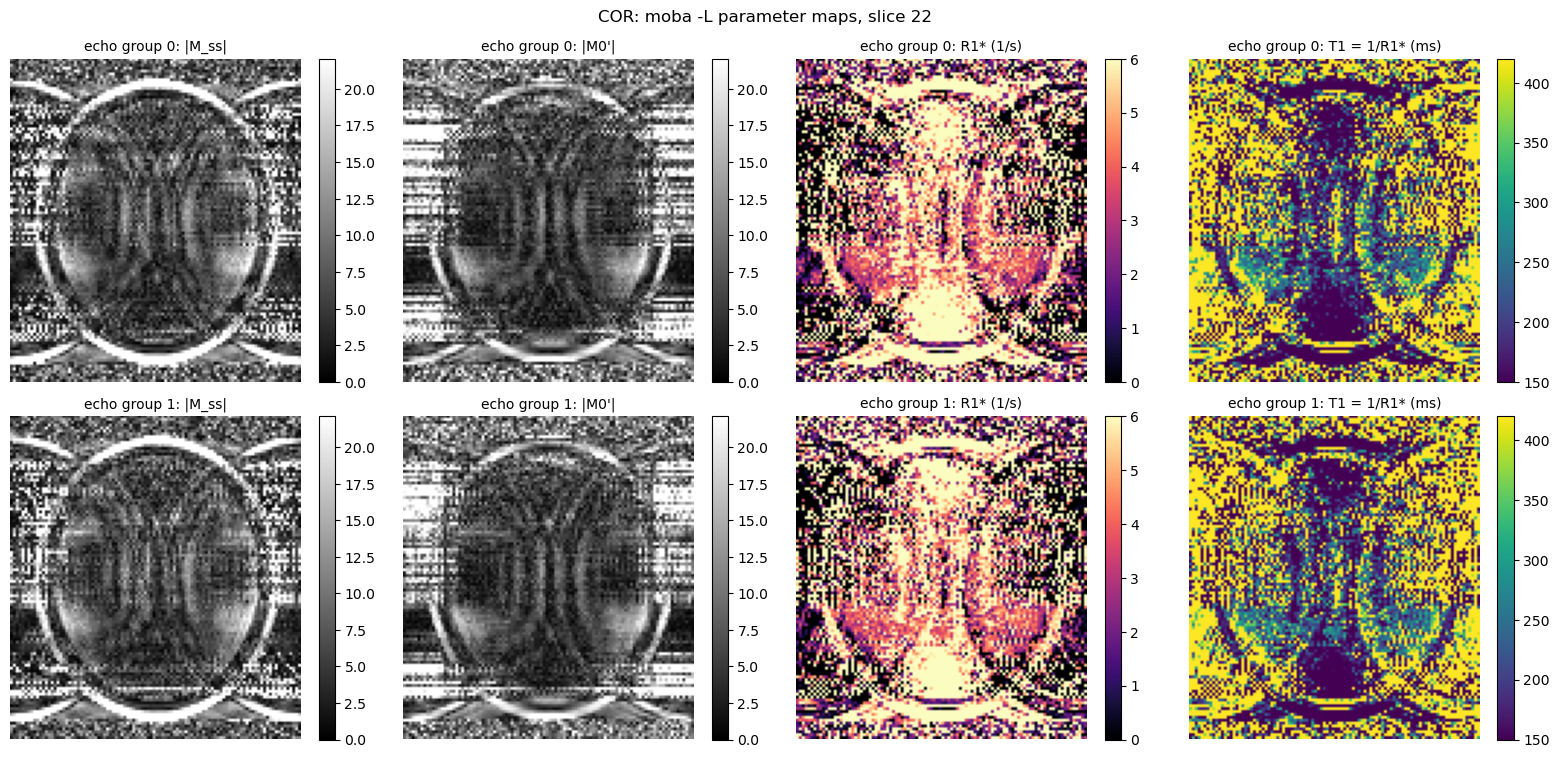

In [9]:
info = scans[PLANE][pu.REF_TI_IDX]['info']
sp = pu.spacing_of(info); ASP = sp[0] / sp[1]
truth = dict(np.load(PHANTOM_DIR / f'truth_{PLANE}.npz'))
head = truth['label'] >= 3                                     # CSF, GM, WM, lesions
z0 = info['matrix'][2] // 2

fig, axes = plt.subplots(2, 4, figsize=(16, 7.6))
for r_, e in enumerate((0, 1)):
    m = rec[PLANE, e]['maps']
    R1 = np.real(m[..., 2])
    vmax = np.percentile(np.abs(m[..., 0])[head], 99.5)
    panels = [(np.abs(m[..., 0]), '|M_ss|', dict(cmap='gray', vmin=0, vmax=vmax)),
              (np.abs(m[..., 1]), "|M0'|", dict(cmap='gray', vmin=0, vmax=vmax)),
              (R1, 'R1* (1/s)', dict(cmap='magma', vmin=0, vmax=6)),
              (1000 / np.maximum(R1, 1e-3), 'T1 = 1/R1* (ms)', dict(cmap='viridis', vmin=150, vmax=420))]
    for c_, (v, ttl, kw) in enumerate(panels):
        ax = axes[r_, c_]
        im = ax.imshow(v[:, :, z0], aspect=ASP, **kw)
        ax.set_title(f'echo group {e}: {ttl}', fontsize=10); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'{PLANE}: moba -L parameter maps, slice {z0}'); plt.tight_layout(); plt.show()

## 9. T1 and echo-group combination

The LLR pipeline averages the *signed images* of the two echo groups before the fit. moba
never produces images, so the two echo groups are combined in the **parameter domain**:
both groups have the same sampling, the same noise and the same T1, only a different
phase, so they get **equal weight**, and the average is taken on **R1*** — the quantity
moba estimates (it is linear in the Gauss-Newton updates, and its noise is closer to
symmetric than that of T1 = 1/R1*): T1 = 1 / mean(R1*_e0, R1*_e1). (For the ~±5 %
differences seen here, the harmonic mean differs from the arithmetic mean of T1 by < 0.1 %.)
Weighting by |M_ss| is not possible across runs, because each run splits signal between
image and coils with its own scale. Both groups are also evaluated separately.

T1 is set to NaN outside the head label (≥ 3), the same mask the LLR reference fits in.

In [10]:
def t1_from(maps_list, mask):
    R1 = np.mean([np.real(m[..., 2]) for m in maps_list], axis=0)
    T1 = np.where(mask & (R1 > 0), 1.0 / np.maximum(R1, 1e-6), np.nan)      # seconds
    return T1.astype(np.float32)


T1_e = {e: t1_from([rec[PLANE, e]['maps']], head) for e in (0, 1)}
T1_moba = t1_from([rec[PLANE, e]['maps'] for e in (0, 1)], head)
d = 100 * (T1_e[1] - T1_e[0]) / T1_moba
print(f'echo 1 vs echo 0 T1 (voxel-wise, head): median {np.nanmedian(d):+.2f} %, '
      f'IQR {np.nanpercentile(d, 25):+.2f} .. {np.nanpercentile(d, 75):+.2f} %')

echo 1 vs echo 0 T1 (voxel-wise, head): median +0.06 %, IQR -37.63 .. +37.81 %


## 10. Validation against the truth

`pu.evaluate_t1`: eroded tissue masks and per-lesion masks; **bias vs ideal** (the
resolution-limited, noise-free, fully sampled reference) is the reconstruction's own error
and the number to compare methods on.

In [11]:
rows = pu.evaluate_t1(T1_moba, truth)
pu.print_eval(rows, f'\n{PLANE}: moba -L, echo groups combined ({ECHO_COMBINE}), {MOBA_TAG}')
rows_e = {}
for e in (0, 1):
    rows_e[e] = pu.evaluate_t1(T1_e[e], truth)
    pu.print_eval(rows_e[e], f'\n{PLANE}: moba -L, echo group {e} only')


COR: moba -L, echo groups combined (mean_R1), 2d_L-l1_i8_C100_j0.01_ph1
true = phantom T1; ideal = fit to fully sampled, noise-free, resolution-limited signal (partial volume only); bias vs ideal = reconstruction alone
region                 n    true   ideal     est     sd  bias% vs ideal% peak PV
WM                 70038   259.8   259.8   607.9 50081.6  134.0     134.0 
GM                  3458   309.3   308.8   654.6 4087.2  111.7     112.0 
CSF                  346  3544.2  3819.2 158746.8 2836302.8 4379.1    4056.5 
lesion 1 (10 mm)      34   338.0   313.7   327.5   72.5   -3.1       4.4    1.00
lesion 2 (6 mm)       10   338.0   304.2   258.2   56.7  -23.6     -15.1    0.75
lesion 3 (4 mm)        4   338.0   293.1   463.8  207.7   37.2      58.2    0.50
lesion 4 (2 mm)        1   338.0   268.3   343.5    0.0    1.6      28.0    0.19
lesion 5 (10 mm)      34   182.0   203.9   201.5   60.1   10.7      -1.2    1.00
lesion 6 (6 mm)        7   182.0   211.5   191.3   49.6    5.1     

In [ ]:
T1_true = truth['T1_ms']; T1_ideal = truth['T1_ideal_ms']
lesion_z = [int(np.argmax(fr.sum(axis=(0, 1)))) for fr in truth['lesion_frac_by_id']]
slices = sorted(set([z0] + lesion_z))[:3]
fig, axes = plt.subplots(len(slices), 4, figsize=(17, 4.2 * len(slices)))
axes = np.atleast_2d(axes)
for r_, z in enumerate(slices):
    for c_, (v, ttl, kw) in enumerate([
            (1000 * T1_moba[:, :, z], 'moba T1 (ms)', dict(cmap='viridis', vmin=150, vmax=420)),
            (T1_ideal[:, :, z], 'ideal (resolution-limited) T1 (ms)', dict(cmap='viridis', vmin=150, vmax=420)),
            (1000 * T1_moba[:, :, z] - T1_ideal[:, :, z], 'moba − ideal (ms)', dict(cmap='RdBu_r', vmin=-60, vmax=60)),
            (1000 * T1_moba[:, :, z] - T1_true[:, :, z], 'moba − true (ms)', dict(cmap='RdBu_r', vmin=-60, vmax=60))]):
        ax = axes[r_, c_]
        im = ax.imshow(np.where(head[:, :, z], v, np.nan), aspect=ASP, **kw)
        ax.contour(truth['lesion_fraction'][:, :, z], [0.25], colors='k', linewidths=0.6)
        ax.set_title(f'slice {z}: {ttl}', fontsize=10); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'{PLANE}: moba T1 vs truth (black contours: lesions)'); plt.tight_layout(); plt.show()

In [ ]:
# Bias vs ideal per region, moba (combined) and each echo group
names = [r['region'] for r in rows]
x = np.arange(len(names)); wdt = 0.27
fig, ax = plt.subplots(figsize=(13, 4))
for k, (lab, rr, col) in enumerate((('moba, echoes combined', rows, '#1f4e79'),
                                     ('echo group 0', rows_e[0], '#7fa7cf'),
                                     ('echo group 1', rows_e[1], '#b9cfe6'))):
    ax.bar(x + (k - 1) * wdt, [r.get('bias_vs_ideal_pct', np.nan) for r in rr], wdt, label=lab, color=col)
ax.axhline(0, color='0.3', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('bias vs ideal (%)'); ax.set_ylim(-40, 40); ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9); ax.set_title(f'{PLANE}: T1 bias vs resolution-limited reference (CSF clipped)')
plt.tight_layout(); plt.show()

## 11. Model-generated TI images and k-space residual

moba returns no TI images, but its model generates them: S(TI) = M_ss − (M_ss + M0')
e^(−TI R1*). Multiplied by the coil RSS (the image/coil scale split is arbitrary) and
referenced to the phase of M_ss, the real part is a **signed** TI image, comparable with
the PSIR input of the LLR pipeline.

Data consistency: the estimated coils × model images are taken back to k-space with the
forward NUFFT and compared with the (phase-demodulated) data, after fitting **one** global
complex scale per echo group (moba works on internally normalised data). A relative
residual close to the noise floor √N·σ/‖y‖ means the model explains the data to within
noise; a residual well above it means structure is left in the data. The adjoint of the
residual, coil-combined and summed over TIs, shows *where*.

In [ ]:
def model_images(maps, TI_arr):
    Mss, M0p, R1 = maps[..., 0], maps[..., 1], np.real(maps[..., 2])
    return Mss[..., None] - (Mss + M0p)[..., None] * np.exp(-np.asarray(TI_arr)[None, None, None, :] * R1[..., None])


def residual_check(scans_plane, e, r):
    matrix = scans_plane[pu.REF_TI_IDX]['info']['matrix']
    T, D, P = pu.stack_tis(scans_plane, e)
    D = D * np.exp(-1j * r['dphi']).reshape(1, 1, 1, 1, 1, -1)
    S = model_images(r['maps'], [s['info']['TI_s'] for s in scans_plane])     # (X, Y, Z, TI)
    S = S * r['rel_scale'][:, None, None, None]                                  # one scale for all slices
    img = (r['sens'][..., None] * S[..., None, :])[:, :, :, :, None, :].astype(np.complex64)
    Y = pu.checked(bart(1, 'nufft', T, img))                                   # (read, pe, coil, TI)
    Y = Y.reshape(D.shape)
    w = (np.abs(D).sum(axis=3, keepdims=True) > 0)                            # sampled (not padded)
    a = np.sum(np.conj(Y) * D * w) / np.sum(np.abs(Y * w) ** 2)
    R = (D - a * Y) * w
    out = []
    for j, s in enumerate(scans_plane):
        n = w[..., j].sum() * D.shape[3]
        yj = np.linalg.norm(D[..., j])
        out.append((np.linalg.norm(R[..., j]) / yj, np.sqrt(n) * s['info']['noise_sd'] / yj))
    rimg = pu.checked(bart(1, 'nufft -a -d {}:{}:{}'.format(*matrix), T, R.astype(np.complex64)))
    cs = r['sens']
    rimg = np.sum(np.conj(cs)[..., None] * rimg, axis=3) / np.maximum(np.sum(np.abs(cs) ** 2, axis=3), 1e-12)[..., None]
    return np.array(out), np.sqrt(np.sum(np.abs(rimg) ** 2, axis=-1)), a


res = {e: residual_check(scans[PLANE], e, rec[PLANE, e]) for e in (0, 1)}
print(f"{'':10s}" + ''.join(f'TI{1000 * t:.0f}'.rjust(20) for t in TI))
for e in (0, 1):
    print(f'echo {e}:   ' + ''.join(f'{a:8.3f} (noise {b:5.3f})' for a, b in res[e][0]))
print('relative k-space residual ‖y − a·A(x)‖/‖y‖ per TI, (noise floor √N·σ/‖y‖)')

In [ ]:
e = 0
m = rec[PLANE, e]['maps']
S = model_images(m, TI)
rss = np.sqrt(np.sum(np.abs(rec[PLANE, e]['sens']) ** 2, axis=3))
signed = np.real(S * (rss * rec[PLANE, e]['rel_scale'][:, None, None])[..., None]
                 * np.exp(-1j * np.angle(m[..., 0]))[..., None])
vmax = np.percentile(np.abs(signed[..., -1])[head], 99)
fig, axes = plt.subplots(1, 5, figsize=(19, 4))
for j in range(4):
    axes[j].imshow(signed[:, :, z0, j], cmap='gray', vmin=-vmax, vmax=vmax, aspect=ASP)
    axes[j].set_title(f'model TI{1000 * TI[j]:.0f}, signed (echo {e})', fontsize=10); axes[j].axis('off')
rimg = res[e][1]
im = axes[4].imshow(rimg[:, :, z0], cmap='inferno', aspect=ASP, vmin=0, vmax=np.percentile(rimg, 99.5))
axes[4].set_title('|adjoint of k-space residual| (RSS over TI)', fontsize=10); axes[4].axis('off')
plt.colorbar(im, ax=axes[4], fraction=0.046)
plt.suptitle(f'{PLANE} slice {z0}'); plt.tight_layout(); plt.show()

## 12. Is the free M0' consistent with the known recovery time?

For this protocol M0'/M_ss should equal 1 − e^(−c R1*) with c = 1.2 s (section 3); moba
does not impose it. The ratio is independent of moba's scale and phase, so it is a free
consistency check of the estimated maps: departures show how much of the curve shape is
absorbed by the extra degree of freedom (noise, or the partial-volume and phase effects).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lab = truth['label']
for e, ax in zip((0, 1), axes):
    m = rec[PLANE, e]['maps']
    ratio = np.real(m[..., 1] / np.where(np.abs(m[..., 0]) > 0, m[..., 0], np.nan))
    pred = 1 - np.exp(-C_NOM * np.real(m[..., 2]))
    for l, name, col in ((5, 'WM', '#1f4e79'), (4, 'GM', '#7fa7cf'), (3, 'CSF', '#c0504d')):
        v = (ratio - pred)[lab == l]
        v = v[np.isfinite(v)]
        ax.hist(np.clip(v, -0.5, 0.5), bins=100, histtype='step', lw=1.5, color=col,
                label=f'{name}: median {np.median(v):+.3f}, IQR {np.subtract(*np.percentile(v, [75, 25])):.3f}')
    ax.set_xlabel("M0'/M_ss − (1 − exp(−1.2 s · R1*))"); ax.set_ylabel('voxels')
    ax.set_title(f'echo group {e}'); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 13. Coil-map QC

moba's coils vs (i) `shared_selfcal(nmaps=1)` — the pipeline's calibration restricted to one
map set, the closest counterpart — and (ii) the true phantom maps (oracle). All maps are
normalised to unit RSS over coils (moba's own RSS carries part of the image intensity), and
compared by the correlation of |map| per coil inside the head; the relative phase between
map sets is irrelevant to T1 (it lands in the complex M_ss/M0').

In [ ]:
def coil_agreement(a, b, mask):
    a = pu.unit_rss(a)[..., 0]; b = pu.unit_rss(b)[..., 0]
    return np.array([np.corrcoef(np.abs(a[..., c])[mask], np.abs(b[..., c])[mask])[0, 1]
                     for c in range(a.shape[3])])


f = PROC_DIR / f'sens_selfcal_m1_{PLANE}_e0.npy'
if f.exists():
    sc1 = np.load(f)
else:
    sc1 = pu.shared_selfcal(scans[PLANE], 0, nmaps=1)[..., 0]
    np.save(f, sc1)
ms = rec[PLANE, 0]['sens']
print('|map| correlation per coil, echo 0, inside the head')
print('  moba vs shared_selfcal(nmaps=1):', np.round(coil_agreement(ms, sc1, head), 3))
print('  moba vs true maps              :', np.round(coil_agreement(ms, truth['sens'], head), 3))
print('  selfcal(1) vs true maps        :', np.round(coil_agreement(sc1, truth['sens'], head), 3))

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for r_, (nm, s) in enumerate((('moba', ms), ('shared_selfcal m=1', sc1), ('true', truth['sens']))):
    u = pu.unit_rss(s)[..., 0]
    for c_ in range(4):
        axes[r_, c_].imshow(np.abs(u[:, :, z0, 2 * c_]), cmap='gray', vmin=0, vmax=1, aspect=ASP)
        axes[r_, c_].set_title(f'{nm}: coil {2 * c_}', fontsize=9); axes[r_, c_].axis('off')
plt.suptitle(f'{PLANE}: |coil maps| (unit RSS), slice {z0}'); plt.tight_layout(); plt.show()

## 14. LLR reference (context only, no tuning of either)

`python synth/run_llr_reference.py <PHANTOM_DIR> COR` writes `llr_COR.npz` (shared-TI
self-calibrated maps, 2 map sets, `pics -e -S -N -R L:7:7:0.006 -i 80 -b 4 -U`, both echo
groups, PSIR, grid fit). Loaded here if present and evaluated with the same function.

In [ ]:
f = PHANTOM_DIR / f'llr_{PLANE}.npz'
if f.exists():
    llr = dict(np.load(f))
    rows_llr = pu.evaluate_t1(llr['T1_s'], truth)
    print(f"{'region':18s} {'true':>7s} {'ideal':>7s} {'LLR':>7s} {'moba':>7s}   {'LLR vs ideal%':>13s} {'moba vs ideal%':>14s}")
    for a, b in zip(rows_llr, rows):
        print(f"{a['region']:18s} {a['true_ms']:7.1f} {a['ideal_ms']:7.1f} {a['est_ms']:7.1f} {b['est_ms']:7.1f}"
              f"   {a['bias_vs_ideal_pct']:13.1f} {b['bias_vs_ideal_pct']:14.1f}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    for ax, v, ttl in ((axes[0], 1000 * llr['T1_s'][:, :, z0], 'LLR T1 (ms)'),
                       (axes[1], 1000 * T1_moba[:, :, z0], 'moba T1 (ms)'),
                       (axes[2], T1_ideal[:, :, z0], 'ideal T1 (ms)')):
        im = ax.imshow(np.where(head[:, :, z0], v, np.nan), cmap='viridis', vmin=150, vmax=420, aspect=ASP)
        ax.set_title(f'{PLANE} slice {z0}: {ttl}'); ax.axis('off'); plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()
else:
    print(f'{f} not found: run synth/run_llr_reference.py first (table in RECON_COMPARISON.md)')

## 15. All three planes

Same code and options for axial and sagittal (`RUN_ALL_PLANES`). Axial has the zero-padded
TI31 (section 4).

In [ ]:
T1_plane = {PLANE: T1_moba}
if RUN_ALL_PLANES:
    for p in PLANES:
        if p == PLANE:
            continue
        for e in (0, 1):
            rec[p, e], state = moba_recon(scans[p], e, p)
            print(f"{p} echo {e}: {state}, moba runtime {float(rec[p, e]['runtime_s']) / 60:.1f} min")
        tr_p = dict(np.load(PHANTOM_DIR / f'truth_{p}.npz'))
        T1_plane[p] = t1_from([rec[p, e]['maps'] for e in (0, 1)], tr_p['label'] >= 3)
        pu.print_eval(pu.evaluate_t1(T1_plane[p], tr_p), f'\n{p}: moba -L, echo groups combined')
else:
    print('RUN_ALL_PLANES = False -- skipped')

In [ ]:
if len(T1_plane) > 1:
    fig, axes = plt.subplots(1, len(T1_plane), figsize=(5 * len(T1_plane), 4.4))
    for ax, (p, v) in zip(np.atleast_1d(axes), T1_plane.items()):
        inf = scans[p][pu.REF_TI_IDX]['info']; s_ = pu.spacing_of(inf)
        im = ax.imshow(1000 * v[:, :, v.shape[2] // 2], cmap='viridis', vmin=150, vmax=420, aspect=s_[0] / s_[1])
        ax.set_title(f'{p}: moba T1 (ms), mid pe2 slice'); ax.axis('off'); plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

## 16. What a per-plane T1 output means for the 3-plane super-resolution step

The planned pipeline (`T1map_3plane_SR_V1.ipynb`, steps 4-5; Deoni et al. 2022) combines
**per-TI images** of the three planes in isotropic space and fits T1 there. moba returns
**parameter maps per plane**, not TI images. Consequences and options:

1. **SR of parameter maps.** Super-resolve T1 (or R1*) directly from the three anisotropic
   T1 maps. The SR forward model (slice profile averaging) is linear in the *signal*, not in
   T1: partial volume across a 5 mm slice mixes signals, and T1 of a mixed signal is not the
   average T1. For small lesions (all ≤ 5 mm in at least one direction) this is exactly the
   regime that matters, so parameter-domain SR would be a biased approximation. R1* mixes
   more linearly than T1 but is still not exact.
2. **SR of model-generated TI images (recommended starting point).** Synthesise signed TI
   images per plane from (M_ss, M0', R1*) (section 11), then run the existing per-TI SR and
   isotropic fit unchanged. Caveats: the images are constrained to the model voxel by
   voxel, so partial-volume voxels are forced onto a mono-exponential curve *before* SR;
   M_ss/M0' carry each run's arbitrary scale and phase, so the planes must be intensity-
   normalised (the coil-RSS scaling used here) and phase-referenced per plane before
   combination; and the synthetic images inherit moba's spatial regularisation.
3. **Registration.** Inter-plane registration needs images: use |M_ss| (proton-density-like)
   or a synthetic TI800 image, not T1 (low contrast between WM and GM at 64 mT).
4. **Joint model-based SR (future).** The principled version is one `moba`-like problem for
   all three planes on the isotropic grid (per-plane slice-profile/resampling operator in
   the forward model, one set of parameter maps). Not available in BART as a tool; it would
   need a custom forward operator.
5. **Per-plane T1 as a reference** (as the SR notebook already plans): moba's per-plane maps
   are a direct voxel-wise check of the isotropic result.

## 17. Report (V1, status at hand-over; work stopped early at the coordinator's request)

**State of this notebook.** Sections 1-10 (tables) were executed on the coronal plane, both
echo groups; their outputs are shown above. **Section 10 figures and sections 11-15 were
written but not executed** (no outputs): bias bar chart, T1-vs-truth figure, model-generated
TI images and k-space residual, M0'/M_ss consistency, coil-map QC, LLR side-by-side,
all-plane run. They have not been debugged; expect small fixes on first run. The LLR
reference was **not** re-run here. Everything ran on the researcher's laptop next to other
heavy BART jobs, so runtimes are inflated.

### What was built
* `moba -L` per plane and echo group from the stacked 4-TI k-space (`pu.stack_tis`, TIs in
  dim 5, trajectory as wrapper kwarg `t=T`), per-TI global phase demodulation, T1 = 1/R1*,
  echo-group combination, evaluation with `pu.evaluate_t1`.
* Reconstruction is **slice-wise along the fully sampled Cartesian readout** (readout iFFT,
  then 112 independent 2D `moba` problems for coronal, 6 in parallel). Cache: `PHANTOM_DIR/moba/`.

### Model-mapping verification (section 3)
* With TR = TI + c, S = M0(1 - 2e^(-TI/T1) + e^(-TR/T1)) is **exactly** moba's
  S = M_ss - (M_ss + M0')e^(-TI R1*), with M_ss = M0, M0' = M0(1 - e^(-c/T1)), R1* = 1/T1.
  The max difference is 4e-16 M0 over T1 0.1-4 s. There is no Look-Locker correction, so
  do not use `looklocker`.
* c = 1.194 s at TI31 vs 1.200 s gives a T1 error (noise-free, 3 free parameters) of
  **< 0.07 % for 180-340 ms** (all brain tissue and lesions), 1.2 % at 1 s and **+11 % for
  CSF (3.5 s)**. With TIs <= 0.8 s the 3-parameter fit is ill-conditioned for long T1.
* TI file: complex, shape (1, 1, 1, 1, 1, 4), in **seconds**, so R1* is in 1/s.

### Design decisions and open choices
* **Axial padding / `-p`:** `moba -p` is a PSF for pre-gridded Cartesian data, not a sample
  weight, so it is not passed. It is not needed either: with `-t`, moba weights only
  non-zero samples (`estimate_pattern`). Section 4 confirms that the padded samples are
  exactly the all-coil-zero samples.
* **Coil maps:** moba does **not** accept external maps. The last positional argument is an
  *output*. `--other ksp-sens` is only an initial value in moba's Sobolev k-space
  representation and is still updated, and `-L` ignores `no-sens-deriv`. moba estimates
  the coils jointly with the maps: shared across TIs, Sobolev-smooth, **one map set only**.
  So the 2-map `shared_selfcal` maps cannot be used. Open option: pass
  `shared_selfcal(nmaps=1)` as the initial value via `ksp-sens`.
* **Per-TI phase:** doubled-angle estimate from per-coil tapered gridding images, then
  demodulation in k-space. Against the true offsets (up to 11°) the error is <= 0.3° at
  TI31/TI400 and 0.8-1.2° (systematic) at TI150. Alternatives are in section 5.
* **Echo groups:** reconstructed separately, then T1 = 1/mean(R1*) with equal weights.
* **3D vs slice-wise:** one 3D call with the same options failed (coronal echo 0, 35 min,
  ~7 GB). The residual stayed at 51 % of the data norm (noise floor about 24 %) and WM T1
  came out at 90 ms. The fixed-norm scaling does not adapt to volume size.

### Options (all untuned)
`moba -L -l1 -i 8 -C 100 -j 0.01 --normalize_scaling --scale_data 5000 --scale_psf 1000`,
default init (M_ss = M0' = 1, R1* = 1/s), `--img_dims 1:ny:nz` per readout slice.

### Validation: coronal plane, echo groups combined

| region | true | ideal | moba mean | bias vs ideal |
|---|---|---|---|---|
| WM | 259.8 | 259.8 | 607.9 (median 250.2) | +134 % (median -3.6 %) |
| GM | 309.3 | 308.8 | 654.6 (median 289.7) | +112 % (median -5.9 %) |
| CSF | 3544 | 3819 | outliers (median 313) | fails |
| lesion 1, 10 mm, long T1 | 338 | 313.7 | 327.5 | +4.4 % |
| lesion 2, 6 mm, long | 338 | 304.2 | 258.2 | -15.1 % |
| lesion 3, 4 mm, long | 338 | 293.1 | 463.8 | +58.2 % |
| lesion 4, 2 mm, long | 338 | 268.3 | 343.5 | +28.0 % (1 voxel) |
| lesion 5, 10 mm, short T1 | 182 | 203.9 | 201.5 | -1.2 % |
| lesion 6, 6 mm, short | 182 | 211.5 | 191.3 | -9.5 % |
| lesion 7, 4 mm, short | 182 | 225.1 | 215.1 | -4.5 % |
| lesion 8, 2 mm, short | 182 | 238.9 | 671.7 | +181 % (1 voxel) |

Medians over the eroded masks: WM 250 ms (IQR 199-325), GM 290 ms (IQR 194-474).
**V1 is not usable yet.** The means are dominated by voxels where R1* goes to 0 (T1 > 1 s in
3.8 % of WM and 14 % of GM), and voxel-wise noise is very large (echo 1 vs echo 0 T1 IQR
±38 %). The solver shows why: in many readout slices the IRGNM **diverges**. The residual
entering the last Newton step reaches up to 22x (echo 0) and 46x (echo 1) the data norm
(median 0.58 / 0.64; noise floor about 0.24), mostly in slices towards the head periphery
(x about 24-32 and 88-95). Central slices converge: slice 76 has residual 0.34 and WM/GM
257 / 312 ms vs ideal 261 / 312. The lesion rows mostly reflect noise, not regularisation
bias. A comparison with LLR is not meaningful yet (LLR in the brief: WM -0.4 %, GM -0.5 %).

**Runtime:** 6.6 min (echo 0) and 8.5 min (echo 1) wall time with 6 parallel single-thread
jobs on a loaded 10-core laptop. That is about 15 s per 2D slice single-threaded. The
phase estimate takes about 5 s per echo.

### Known limitations / not done
* The solver is unstable in peripheral slices; this is the first thing to fix. A diagnostic
  run on a diverging slice (x = 26, `-d 5`) was started but stopped before it produced output.
* Section 10 figures and sections 11-15 are not executed. AX and SAG are not reconstructed,
  and the LLR reference was not re-run.
* CSF: the model is ill-conditioned at these TIs (+11 % from the c mismatch alone), on top
  of the instability.
* Slice-wise 2D: regularisation and coil smoothness act only within each (pe1, pe2) plane,
  and each slice has its own normalisation (handled by `rel_scale`).
* M0' is free (not tied to c and T1), so moba fits 3 parameters where the PSIR fit uses 2.

### Parameters to tune (with the researcher)
1. Data/PSF scaling (`--scale_data`, `--scale_psf`, `--normalize_scaling`): sets the effective
   regularisation. It must adapt to volume/slice size (this would also allow 3D).
2. `-j` (alpha_min) and `-R` (regularisation strength and schedule).
3. `-i` Newton steps and `-C` inner iterations (the divergence happens at late, weakly
   regularised steps).
4. `-s` FISTA step, `-B` lower bound on R1*, `--other pinit` (initial values), and
   `--other pscale` (balancing R1* against M_ss/M0', as in Wang 2018).
5. Regulariser type (`-l1`, `-l2`, or `-r` terms per map).
6. Coil initialisation (`ksp-sens` from `shared_selfcal(nmaps=1)`) and Sobolev coil parameters.
7. `PHASE_TAPER` (minor) and echo-group weighting.